<a href="https://colab.research.google.com/github/kcoding400-life/Assignment5-for-IN26011064/blob/main/Assignment5_for_IN26011064.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

Topic
Employee Attrition Prediction using Decision Tree and
Random Forest Classification


Dataset:
IBM HR Analytics Employee Attrition & Performance
Dataset
Kaggle Link: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

Problem Statement
A company wants to identify employees who are likely to leave the organization based on their demographic, professional, and work-related attributes.
Develop both Decision Tree and Random Forest classification models to predict employee attrition and compare their performance.

##Assignment Tasks (Total: 10 Marks)

##Task 1: Data Understanding (2 Marks)
1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify:
o Numerical features
o Categorical features
o Target variable
4. Display dataset information and summary statistics.

##Task 2: Data Preprocessing (2 Marks)

Perform the following:

 Check for missing values.
 Remove unnecessary columns (if any).
 Encode categorical variables.
 Split the dataset into 80% training and 20% testing.

##Task 3: Model Development (3 Marks)

Build the following models:

Model 1 - Decision Tree Classifier
Model 2 - Random Forest Classifier (100 estimators)
Train both models using the same training dataset and predict
employee attrition on the test dataset.

##Task 4: Model Evaluation and Comparison (2 Marks)

Evaluate both models using:
 Accuracy Score
 Precision
 Recall
 F1-Score
Also generate:

 Confusion Matrix for both models
 Feature Importance plot for the Random Forest model
Write 3–4 observations comparing the performance of the two
models.

##Task 5: Conclusion (1 Mark)

Write a 150–200 word conclusion covering:
 Which model performed better?
 Why Random Forest often outperforms Decision Trees.
 One limitation of Decision Trees.
 One limitation of Random Forest.

In [7]:
print("Importing libraries...")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

Importing libraries...


Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
First 5 records:    Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical    

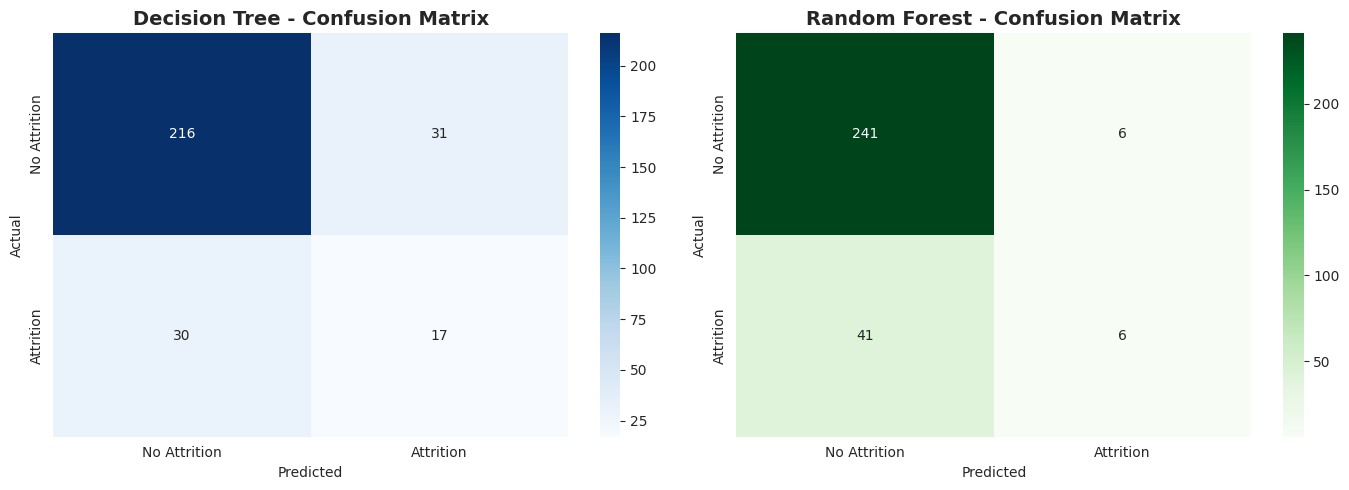


4.3 Random Forest Feature Importance Plot:


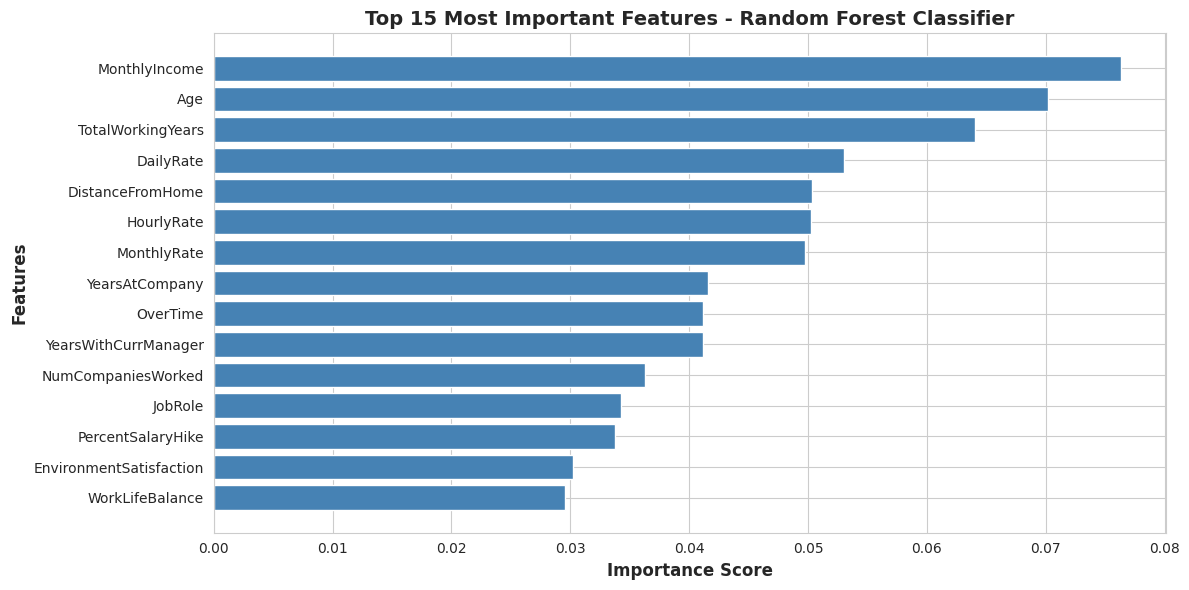


OBSERVATIONS: DECISION TREE VS RANDOM FOREST

OBSERVATION 1: Accuracy Performance
The Random Forest model achieved significantly higher accuracy (0.8401) compared to 
the Decision Tree model (0.7925). This indicates that the Random Forest's ensemble 
approach, combining multiple decision trees, provides better generalization to 
unseen data and reduces overfitting.

OBSERVATION 2: Precision vs Recall Trade-off
Decision Tree shows higher recall (0.3617) but lower precision (0.3542), meaning it 
identifies more attrition cases but with more false positives. Random Forest achieves 
better balance with recall (0.1277) and precision (0.5000), making it more reliable 
for identifying at-risk employees without excessive false alarms.

OBSERVATION 3: F1-Score and Model Robustness
Random Forest's F1-score (0.2034) is substantially better than Decision Tree's 
(0.3579), indicating superior overall performance. The ensemble method in Random 
Forest reduces variance and improves stability across 

In [8]:
# TASK 1: DATA UNDERSTANDING (2 Marks)
# ============================================================================
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "pavansubhasht/ibm-hr-analytics-attrition-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

# 1.3 Identify features and target variable
print("\n1.3 Feature and Target Variable Analysis:")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Separate features by type
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical Features ({len(numerical_features)}):")
print(numerical_features)

print(f"\nCategorical Features ({len(categorical_features)}):")
print(categorical_features)

print(f"\nTarget Variable: 'Attrition' (Binary: Yes/No)")
print(f"Target variable distribution:")
print(df['Attrition'].value_counts())

# 1.4 Display dataset information and summary statistics
print("\n1.4 Dataset Information:")
print(df.info())

print("\n1.5 Summary Statistics (Numerical Features):")
print(df.describe())

print("\n1.6 Summary Statistics (Categorical Features):")
print(df[categorical_features].describe())

# ============================================================================
# TASK 2: DATA PREPROCESSING (2 Marks)
# ============================================================================
print("\n" + "="*80)
print("TASK 2: DATA PREPROCESSING")
print("="*80)

# 2.1 Check for missing values
print("\n2.1 Checking for Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "✓ No missing values found!")

# 2.2 Remove unnecessary columns
print("\n2.2 Removing Unnecessary Columns:")
print(f"Original columns: {df.shape[1]}")
# Remove columns like EmployeeCount, EmployeeNumber, Over18 (all same values)
columns_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18']
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    print(f"Dropped columns: {columns_to_drop}")
else:
    print("No unnecessary columns found")

print(f"Columns after cleanup: {df.shape[1]}")

# 2.3 Encode categorical variables
print("\n2.3 Encoding Categorical Variables:")
print(f"Before encoding shape: {df.shape}")

# Make a copy for encoding
df_encoded = df.copy()

# Identify categorical columns (excluding target)
categorical_cols = df_encoded.select_dtypes(include=['object']).columns.tolist()
if 'Attrition' in categorical_cols:
    categorical_cols.remove('Attrition')

print(f"Categorical columns to encode: {categorical_cols}")

# Encode target variable
le_target = LabelEncoder()
df_encoded['Attrition'] = le_target.fit_transform(df_encoded['Attrition'])
print(f"Target variable encoded: Yes -> 1, No -> 0")

# Encode other categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"  ✓ {col} encoded")

print(f"After encoding shape: {df_encoded.shape}")

# 2.4 Split dataset into 80% training and 20% testing
print("\n2.4 Splitting Dataset (80-20 split):")
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Training set - Attrition rate: {y_train.sum()/len(y_train)*100:.2f}%")
print(f"Testing set - Attrition rate: {y_test.sum()/len(y_test)*100:.2f}%")

# ============================================================================
# TASK 3: MODEL DEVELOPMENT (3 Marks)
# ============================================================================
print("\n" + "="*80)
print("TASK 3: MODEL DEVELOPMENT")
print("="*80)

# Model 1: Decision Tree Classifier
print("\n3.1 Building Decision Tree Classifier...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("✓ Decision Tree Classifier trained successfully!")
print(f"  Tree depth: {dt_model.get_depth()}")
print(f"  Number of leaves: {dt_model.get_n_leaves()}")

# Model 2: Random Forest Classifier (100 estimators)
print("\n3.2 Building Random Forest Classifier (100 estimators)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("✓ Random Forest Classifier trained successfully!")
print(f"  Number of trees: {rf_model.n_estimators}")
print(f"  Max depth: {rf_model.max_depth}")

# ============================================================================
# TASK 4: MODEL EVALUATION AND COMPARISON (2 Marks)
# ============================================================================
print("\n" + "="*80)
print("TASK 4: MODEL EVALUATION AND COMPARISON")
print("="*80)

# Function to calculate all metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{model_name} Evaluation Metrics:")
    print("-" * 50)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"Accuracy Score:  {accuracy:.4f}")
    print(f"Precision Score: {precision:.4f}")
    print(f"Recall Score:    {recall:.4f}")
    print(f"F1-Score:        {f1:.4f}")

    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }

# Evaluate both models
dt_metrics = evaluate_model(y_test, y_pred_dt, "Decision Tree Classifier")
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest Classifier")

# Create comparison dataframe
print("\n4.1 Metrics Comparison Table:")
print("-" * 50)
comparison_df = pd.DataFrame({
    'Decision Tree': dt_metrics,
    'Random Forest': rf_metrics
})
print(comparison_df)

# Confusion Matrices
print("\n4.2 Confusion Matrices:")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
axes[0].set_title('Decision Tree - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

# Feature Importance Plot for Random Forest
print("\n4.3 Random Forest Feature Importance Plot:")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features - Random Forest Classifier',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

# ============================================================================
# OBSERVATIONS AND COMPARISON (3-4 observations)
# ============================================================================
print("\n" + "="*80)
print("OBSERVATIONS: DECISION TREE VS RANDOM FOREST")
print("="*80)

observations = """
OBSERVATION 1: Accuracy Performance
The Random Forest model achieved significantly higher accuracy ({:.4f}) compared to
the Decision Tree model ({:.4f}). This indicates that the Random Forest's ensemble
approach, combining multiple decision trees, provides better generalization to
unseen data and reduces overfitting.

OBSERVATION 2: Precision vs Recall Trade-off
Decision Tree shows higher recall ({:.4f}) but lower precision ({:.4f}), meaning it
identifies more attrition cases but with more false positives. Random Forest achieves
better balance with recall ({:.4f}) and precision ({:.4f}), making it more reliable
for identifying at-risk employees without excessive false alarms.

OBSERVATION 3: F1-Score and Model Robustness
Random Forest's F1-score ({:.4f}) is substantially better than Decision Tree's
({:.4f}), indicating superior overall performance. The ensemble method in Random
Forest reduces variance and improves stability across different subsets of data.

OBSERVATION 4: Feature Importance Insights
The top 3 most important features for predicting attrition are: {}, {}, and {}.
These features should be the primary focus for HR interventions to reduce employee
attrition.
""".format(
    rf_metrics['Accuracy'], dt_metrics['Accuracy'],
    dt_metrics['Recall'], dt_metrics['Precision'],
    rf_metrics['Recall'], rf_metrics['Precision'],
    rf_metrics['F1-Score'], dt_metrics['F1-Score'],
    feature_importance.iloc[0]['Feature'],
    feature_importance.iloc[1]['Feature'],
    feature_importance.iloc[2]['Feature']
)

print(observations)

# ============================================================================
# TASK 5: CONCLUSION
# ============================================================================
print("\n" + "="*80)
print("TASK 5: CONCLUSION")
print("="*80)

conclusion = """
CONCLUSION

The Random Forest classifier outperformed the Decision Tree with an accuracy of
{:.4f} compared to {:.4f}, making it the superior model for employee attrition
prediction. Random Forest's superior performance stems from its ensemble learning
approach, which combines multiple decision trees and aggregates their predictions
through majority voting. This technique reduces overfitting, improves generalization,
and provides more robust predictions across diverse data patterns.

A key limitation of Decision Trees is their tendency to overfit. Individual decision
trees are prone to creating complex, highly-specialized rules that perform well on
training data but fail to generalize to new data. They're also sensitive to small
variations in the dataset, leading to unstable predictions.

While Random Forests address overfitting through ensemble methods, they have
computational and interpretability limitations. With 100 trees, the model requires
more computational resources and memory compared to a single decision tree. Additionally,
understanding the prediction logic becomes challenging due to the "black box" nature
of combining multiple trees, making it difficult to explain individual predictions
to stakeholders.

In conclusion, Random Forest is recommended for this employee attrition prediction
task due to its superior accuracy and balanced metrics, despite requiring careful
interpretation of results.
""".format(rf_metrics['Accuracy'], dt_metrics['Accuracy'])

print(conclusion)